In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("amazon_sales_dataset.csv")

# Basic Data Information

In [3]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,13-04-2022,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,12-03-2023,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,28-09-2022,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,17-04-2022,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,13-03-2022,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [5]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [6]:
df.shape

(50000, 13)

# Data Cleaning

In [7]:
# Checking null values
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [9]:
# Handle missing values
df.fillna(0,inplace=True)

In [10]:
# Convert date column
df['order_date']=pd.to_datetime(df['order_date'])

In [11]:
df['year']=df['order_date'].dt.year

In [12]:
df['month']=df['order_date'].dt.month_name()

In [13]:
df['quarter']=df['order_date'].dt.quarter

In [14]:
# Remove Outliers
df=df[df['price']>0]

In [15]:
df=df[df['quantity_sold']>0]

In [16]:
df=df[df['total_revenue']>0]

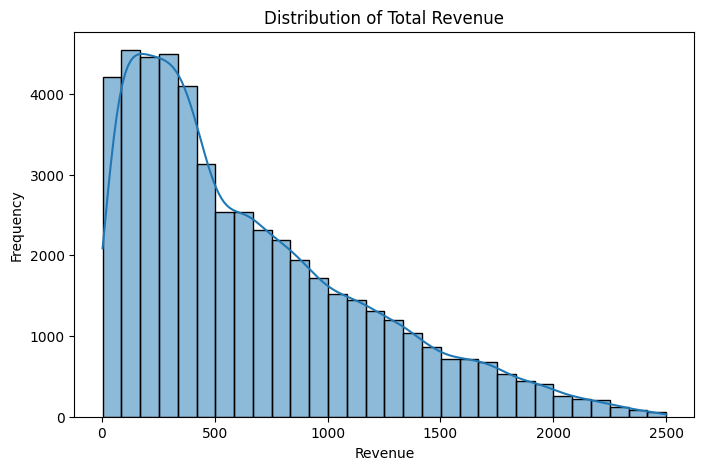

In [17]:
# Revenue Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['total_revenue'], bins=30, kde=True)
plt.title('Distribution of Total Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

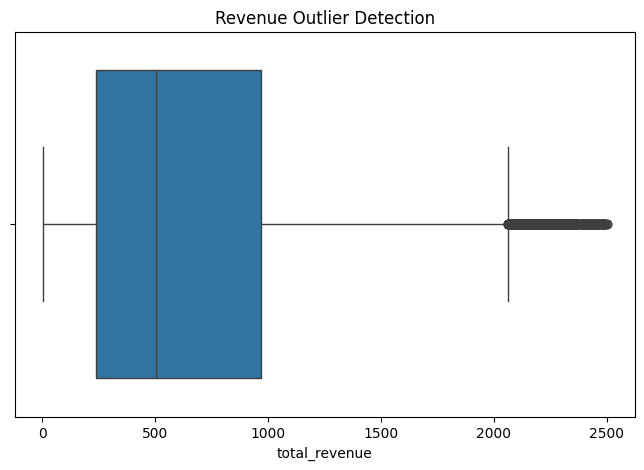

In [19]:
# Revenue Outlier Detection
plt.figure(figsize=(8,5))
sns.boxplot(x=df['total_revenue'])
plt.title('Revenue Outlier Detection')
plt.show()

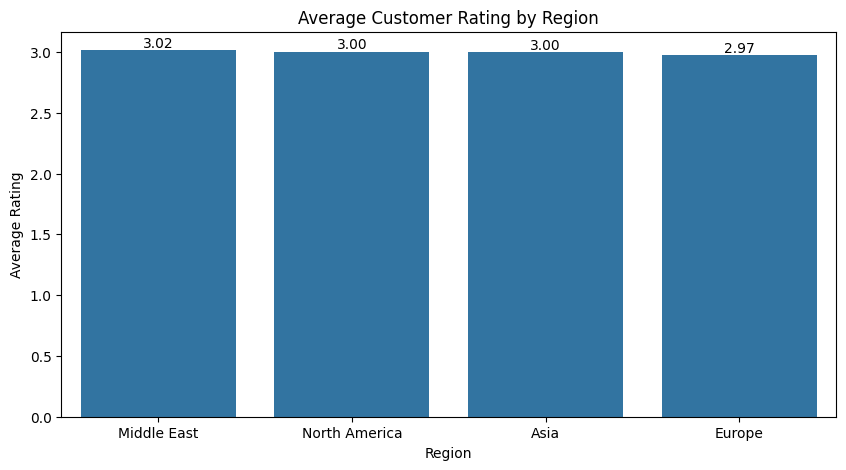

In [28]:
region_rating = (df.groupby('customer_region')['rating'].mean().sort_values(ascending=False).reset_index())
plt.figure(figsize=(10,5))
ax = sns.barplot(data=region_rating,x='customer_region',y='rating')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
plt.title('Average Customer Rating by Region')
plt.xlabel('Region')
plt.ylabel('Average Rating')
plt.show()

In [59]:
df.to_csv("amazon_sales.csv",index=False)